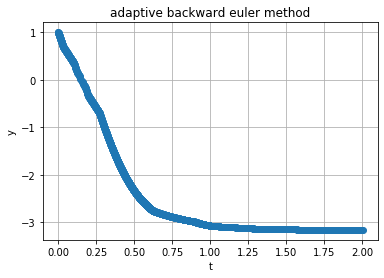

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# function
def f(t, y):
    return y**2 - 10

# derivative of f with respect to y
def fprime(y):
    return 2*y


# Newton-Raphson for single step with Backward Euler
def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):
    y_next = y  # initial guess
    
    for _ in range(max_iter):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)
        
        if abs(g_prime_val) < tol:
            break
        
        y_new = y_next - g_val / g_prime_val
        
        if abs(y_new - y_next) < tol:
            return y_new
        
        y_next = y_new
    
    return y_next


# Adaptive Backward Euler
def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0]
    y_values = [y0]
    
    h = h_init
    t = t0
    y = y0
    
    while t < tf:
        if t + h > tf:
            h = tf - t
        
        y_full = backward_euler_step(f, y, t, h, tol, max_iter)
        
        h_half = h / 2
        y_half_1 = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)
        
        error = abs(y_full - y_half_2)
        
        if error > tol:
            h /= 2
            continue
        elif error < tol / 2:
            h *= 2
        
        t += h
        y = y_half_2
        
        t_values.append(t)
        y_values.append(y)
    
    return np.array(t_values), np.array(y_values)


# initial values
y0 = 1
t0 = 0
tf = 2
h_init = 0.1

# run method
t_values, y_values = backward_euler_adaptive(f, y0, t0, tf, h_init)

# plot results
plt.plot(t_values, y_values, marker='o')
plt.xlabel("t")
plt.ylabel("y")
plt.title("adaptive backward euler method")
plt.grid(True)
plt.show()

I used ChatGPT to help debug and clean up my Python code for the Backward Euler method, mainly to fix formatting and small errors. The prompt I used was: “fix and clean up my backward euler adaptive code for y^2 - 10 and make sure it runs.” The AI helped with syntax and structure, but the overall approach and implementation were my own.